In [ ]:
#import packages
from __future__ import print_function
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
import pandas as pd
import numpy as np
from keras.optimizers import Adam, SGD
# import warnings
# warnings.filterwarnings('ignore')
import cv2
from tensorflow.keras.utils import img_to_array, array_to_img, load_img, to_categorical
# from keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_lbl1 = pd.read_csv(r'/content/drive/MyDrive/pisc/f33.csv') #annotations.csv /content/drive/MyDrive/pisc/ann5k_f.csv')

df_lbl1

,id_name,relation
0,1,4
1,2,1
2,3,4
3,4,4
4,5,4
...,...,...
32997,32998,1
32998,32999,6
32999,33000,6
33000,33001,4


In [ ]:
import zipfile
dn='/content/drive/MyDrive/pisc/allimgd40.npy.zip' #allimg.npy.zip#/content/drive/MyDrive/pisc/d7027.npy.zip'
zip_ref = zipfile.ZipFile(dn, "r")
zip_ref.extractall('/content/drive/MyDrive/pisc/')
zip_ref.close()

In [ ]:
data_x = []
data_x=np.load('/content/drive/MyDrive/pisc/f33.npy') #/content/drive/MyDrive/pisc/d7027.npy')

In [ ]:
data_y = []
for index, row in df_lbl1.iterrows():
  data_y.append(int(row['relation']))

In [ ]:
uniques, ids = np.unique(data_y, return_inverse=True)
labels1 = to_categorical(ids)
labels=ids
labels1

array([[0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)

In [ ]:
from sklearn.model_selection import train_test_split

#Splitting
X_train, X_test, y_train, y_test = train_test_split(data_x, labels1, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print("Train: ", len(X_train), " Test; ",len(X_val), " Test: ",len(X_test))

Train:  26401  Test;  3300  Test:  3301


In [ ]:
import random
from sklearn.model_selection import train_test_split

# Assuming you have X_train, y_train, X_val, and y_val defined

# Function to randomly select a subset of data and labels
def random_subset(data, labels, num_samples):
    # Get a list of random indices without replacement
    random_indices = random.sample(range(len(data)), num_samples)
    # Use the random indices to get the subset
    data_subset = data[random_indices]
    labels_subset = labels[random_indices]
    return data_subset, labels_subset

# Define the number of images you want per subset
num_images_train_subset = 20001
num_images_val_subset = 2500

# Get the subsets for X_train and y_train
X_train_subset, y_train_subset = random_subset(X_train, y_train, num_images_train_subset)

# Get the subsets for X_val and y_val
X_val_subset, y_val_subset = random_subset(X_val, y_val, num_images_val_subset)

# Now you have subsets for X_train, y_train, X_val, and y_val
# X_train_subset and y_train_subset contain 20001 random images each from X_train and y_train
# X_val_subset and y_val_subset contain 2500 random images each from X_val and y_val

print("Train Subset: ", len(X_train_subset), " Val Subset: ", len(X_val_subset))


Train Subset:  20001  Val Subset:  2500


In [ ]:
print(X_train_subset.shape)
print(y_train_subset.shape)
input_shape = X_train[0].shape
print(input_shape)

(20001, 224, 224, 3)
(20001, 6)
(224, 224, 3)


In [ ]:
print(y_train_subset.dtype)

float32


In [ ]:
y_train_l = np.argmax(y_train_subset, axis=1)
ul = np.unique(y_train_l)
print(ul)

[0 1 2 3 4 5]


In [ ]:
y_val_l = np.argmax(y_val_subset, axis=1)
ulv = np.unique(y_val_l)
print(ulv)

[0 1 2 3 4 5]


In [ ]:
y_test_l = np.argmax(y_test, axis=1)
ult = np.unique(y_test_l)
print(ult)

[0 1 2 3 4 5]


In [ ]:
# y1_train = y_train.astype(int)

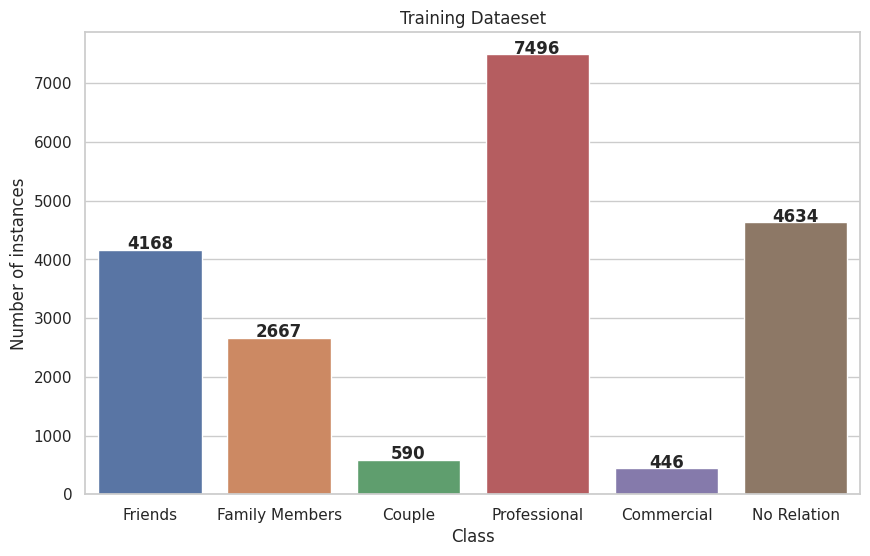

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
#class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_train_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Training Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts)
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

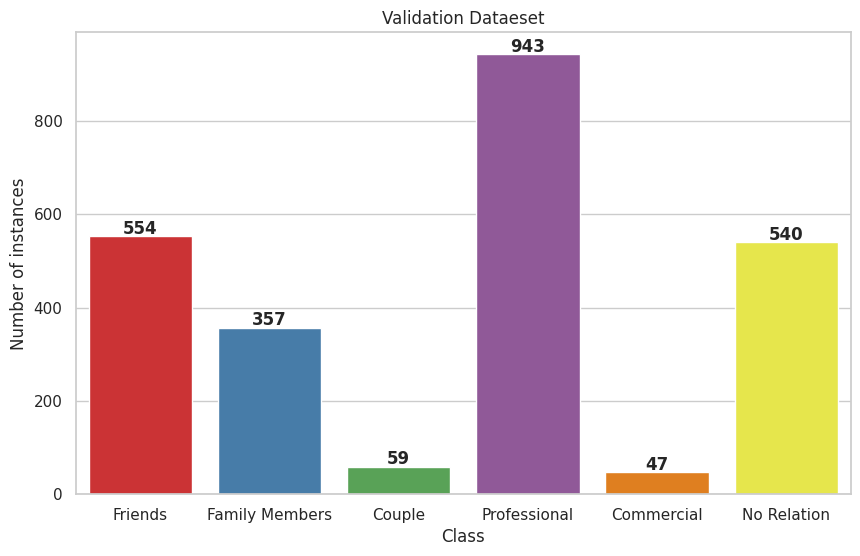

In [ ]:
class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
#class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_val_l:
    class_counts[label] += 1



sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Validation Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Set1")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")


for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

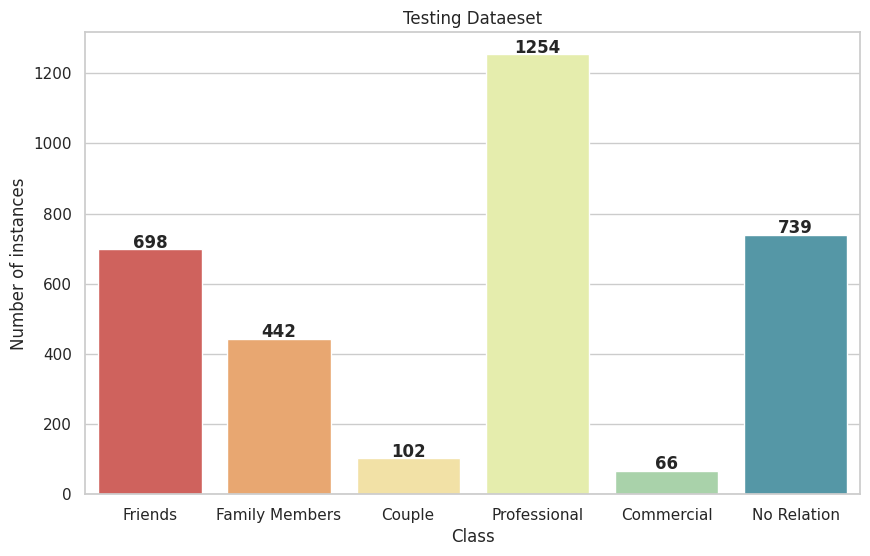

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
#class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_test_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Testing Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Spectral")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

In [ ]:
import tensorflow as tf

# Load the saved models
models = []
num_models = 5

for i in range(num_models):
    model_path = f"/content/drive/MyDrive/pisc/cum_{i}.h5"
    model = tf.keras.models.load_model(model_path)
    models.append(model)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, average_precision_score

# ... (previous code)

# Evaluate the ensemble on the test dataset
ensemble_loss, ensemble_accuracy = models[0].evaluate(X_test, y_test)

# Collect the predictions and ground truth labels for the ensemble
ensemble_predictions = []
ground_truth_labels = []
for model in models:
    predictions = model.predict(X_test)
    ensemble_predictions.append(predictions)
    # Assuming the labels are one-hot encoded, convert them back to integers
    labels = np.argmax(predictions, axis=1)
    ground_truth_labels.append(labels)

# Combine the predictions from the ensemble
ensemble_predictions = np.mean(ensemble_predictions, axis=0)
# Convert the ensemble predictions back to integer labels
ensemble_labels = np.argmax(ensemble_predictions, axis=1)

# Convert the ground truth labels to a flat array
ground_truth_labels = np.concatenate(ground_truth_labels)


126/126 [==============================] - 3s 17ms/step


In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

# Assuming ensemble_predictions is the array containing ensemble model predictions
# Assuming y_test is the true labels for the test set

# Reshape the ensemble predictions and true labels for consistency
reshaped_ensemble_preds = np.reshape(ensemble_predictions, (ensemble_predictions.shape[0], -1))
reshaped_y_test = np.reshape(y_test, (y_test.shape[0], -1))

# Calculate the mean average precision
mean_average_precision = average_precision_score(reshaped_y_test, reshaped_ensemble_preds, average='macro')

print("Mean Average Precision:", mean_average_precision)


Mean Average Precision: 0.949275333537737


In [ ]:
from sklearn.metrics import classification_report

# Assuming ensemble_predictions is the array containing ensemble model predictions
# Assuming y_test is the true labels for the test set

# Reshape the ensemble predictions and true labels for consistency
reshaped_ensemble_preds = np.reshape(ensemble_predictions, (ensemble_predictions.shape[0], -1))
reshaped_y_test = np.reshape(y_test, (y_test.shape[0], -1))

# Convert the predictions to class labels
predicted_labels = np.argmax(reshaped_ensemble_preds, axis=1)
true_labels = np.argmax(reshaped_y_test, axis=1)

# Generate the classification report
classification_rep = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(classification_rep)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1416
           1       0.91      0.88      0.90      1332
           2       0.88      0.91      0.90      1253

    accuracy                           0.90      4001
   macro avg       0.90      0.90      0.90      4001
weighted avg       0.90      0.90      0.90      4001



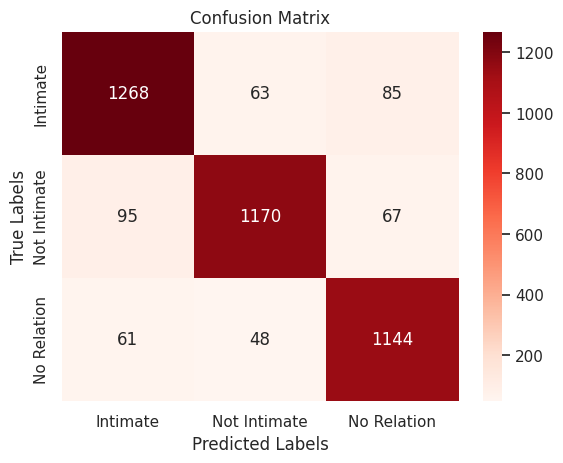

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ensemble_predictions is the array containing ensemble model predictions
# Assuming y_test is the true labels for the test set

# Reshape the ensemble predictions and true labels for consistency
reshaped_ensemble_preds = np.reshape(ensemble_predictions, (ensemble_predictions.shape[0], -1))
reshaped_y_test = np.reshape(y_test, (y_test.shape[0], -1))

# Convert the predictions to class labels
predicted_labels = np.argmax(reshaped_ensemble_preds, axis=1)
true_labels = np.argmax(reshaped_y_test, axis=1)

# Generate the confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

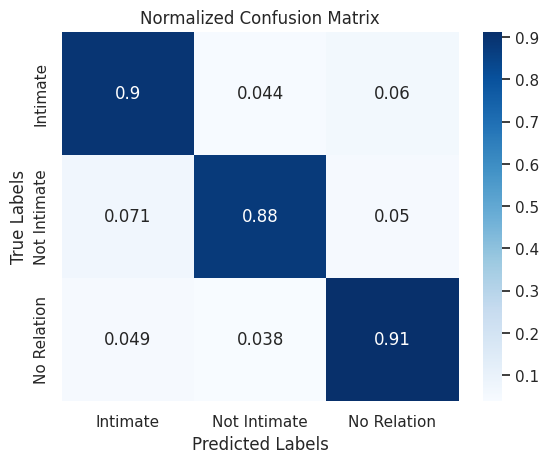

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ensemble_predictions is the array containing ensemble model predictions
# Assuming y_test is the true labels for the test set

# Reshape the ensemble predictions and true labels for consistency
reshaped_ensemble_preds = np.reshape(ensemble_predictions, (ensemble_predictions.shape[0], -1))
reshaped_y_test = np.reshape(y_test, (y_test.shape[0], -1))

# Convert the predictions to class labels
predicted_labels = np.argmax(reshaped_ensemble_preds, axis=1)
true_labels = np.argmax(reshaped_y_test, axis=1)

# Generate the confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)

# Calculate the normalized confusion matrix
normalized_confusion_mat = confusion_mat.astype('float') / confusion_mat.sum(axis=1)[:, np.newaxis]

# Plot the confusion matrix
class_names = ['Intimate', 'Not Intimate', 'No Relation']
sns.heatmap(normalized_confusion_mat, annot=True, cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
